In [2]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [ ]:
# DATA UNDERSTANDING

In [4]:
df = pd.DataFrame(pd.read_csv("Combined Data.csv"))
print(df.head(50))

    Unnamed: 0                                          statement   status
0            0                                         oh my gosh  Anxiety
1            1  trouble sleeping, confused mind, restless hear...  Anxiety
2            2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3            3  I've shifted my focus to something else but I'...  Anxiety
4            4  I'm restless and restless, it's been a month n...  Anxiety
5            5  every break, you must be nervous, like somethi...  Anxiety
6            6  I feel scared, anxious, what can I do? And may...  Anxiety
7            7    Have you ever felt nervous but didn't know why?  Anxiety
8            8  I haven't slept well for 2 days, it's like I'm...  Anxiety
9            9                 I'm really worried, I want to cry.  Anxiety
10          10  always restless every night, even though I don...  Anxiety
11          11  I'm confused, I'm not feeling good lately. Eve...  Anxiety
12          12  sometimes

In [6]:
print("Jumlah baris:", len(df))
print("Jumlah kolom:", len(df.columns))

Jumlah baris: 53043
Jumlah kolom: 3


In [9]:
df.columns

Index(['Unnamed: 0', 'statement', 'status'], dtype='object')

In [10]:
df["length"] = df["statement"].astype(str).apply(lambda x: len(x.split()))
print("Panjang rata-rata setiap baris:", df["length"].mean())

Panjang rata-rata setiap baris: 112.39328469355051


In [11]:
print("Jumlah duplikasi:", df.duplicated().sum())

Jumlah duplikasi: 0


In [12]:
print(df.isnull().sum())

Unnamed: 0      0
statement     362
status          0
length          0
dtype: int64


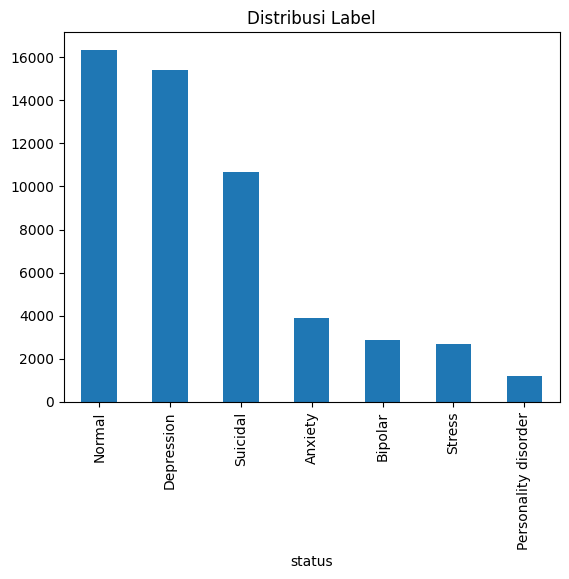

In [14]:
df["status"].value_counts().plot(kind="bar", title="Distribusi Label")
plt.show()

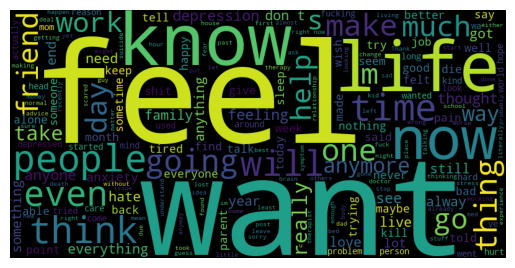

In [16]:
all_text = " ".join(df["statement"].astype(str).tolist())
wordcloud = WordCloud(width=800, height=400).generate(all_text)
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [ ]:
# TEXT PREPROCESSING

In [28]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
nltk.download('stopwords')

stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

def preprocess_text(statement):
    text = statement.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)
    text = re.sub(r"\d+", "", text)
    text = " ".join([lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words])
    return text

df["cleaned_statement"] = df["statement"].astype(str).apply(preprocess_text)

print(df[["statement", "cleaned_statement"]].head(10))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\fahmianoor\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                           statement  \
0                                         oh my gosh   
1  trouble sleeping, confused mind, restless hear...   
2  All wrong, back off dear, forward doubt. Stay ...   
3  I've shifted my focus to something else but I'...   
4  I'm restless and restless, it's been a month n...   
5  every break, you must be nervous, like somethi...   
6  I feel scared, anxious, what can I do? And may...   
7    Have you ever felt nervous but didn't know why?   
8  I haven't slept well for 2 days, it's like I'm...   
9                 I'm really worried, I want to cry.   

                                   cleaned_statement  
0                                            oh gosh  
1  trouble sleeping confused mind restless heart ...  
2  wrong back dear forward doubt stay restless re...  
3  ive shifted focus something else im still worried  
4                im restless restless month boy mean  
5  every break must nervous like something wrong ... 

In [29]:
from nltk.tokenize import word_tokenize, sent_tokenize
nltk.download('punkt')
df["tokenized_statement"] = df["cleaned_statement"].apply(word_tokenize)
df["sent_tokenized_statement"] = df["cleaned_statement"].apply(sent_tokenize)
print(df[["cleaned_statement", "tokenized_statement", "sent_tokenized_statement"]].head(10))


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\fahmianoor\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


                                   cleaned_statement  \
0                                            oh gosh   
1  trouble sleeping confused mind restless heart ...   
2  wrong back dear forward doubt stay restless re...   
3  ive shifted focus something else im still worried   
4                im restless restless month boy mean   
5  every break must nervous like something wrong ...   
6         feel scared anxious may family u protected   
7                       ever felt nervous didnt know   
8         havent slept well day like im restless huh   
9                         im really worried want cry   

                                 tokenized_statement  \
0                                         [oh, gosh]   
1  [trouble, sleeping, confused, mind, restless, ...   
2  [wrong, back, dear, forward, doubt, stay, rest...   
3  [ive, shifted, focus, something, else, im, sti...   
4         [im, restless, restless, month, boy, mean]   
5  [every, break, must, nervous, like, somethin

In [ ]:
# VECTORIZE TEXT

In [30]:
import sklearn as sklearn
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df["cleaned_statement"])
y = df["status"] 

In [ ]:
# DATA SPLITTING

In [31]:
import sklearn as sklearn
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# MODELING SVM

In [32]:
import sklearn as sklearn
from sklearn.svm import SVC

model = SVC(kernel="linear")
model.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [ ]:
# EVALUATION

In [33]:
y_pred = model.predict(X_test)

In [ ]:
# CONFUSION MATRIX

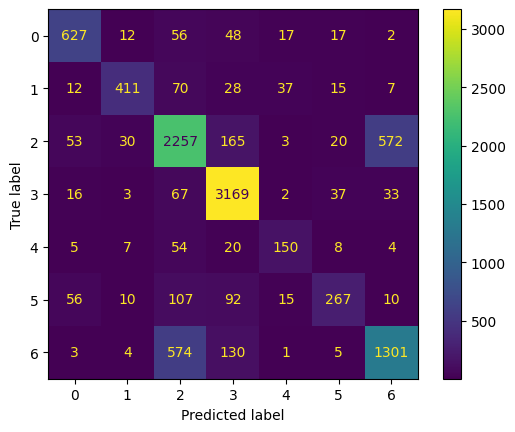

In [34]:
import sklearn as sklearn
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [43]:
def predict_statement(statement):
    cleaned_statement = preprocess_text(statement)
    vectorized_statement = vectorizer.transform([cleaned_statement])
    prediction = model.predict(vectorized_statement)
    return prediction[0]

print(predict_statement("I feel hopeless lately."))
print(predict_statement("I’ve been feeling unhappy most days."))
print(predict_statement("Everything seems pointless."))

Depression
Normal
Depression


In [ ]:
# CLASSIFICATION REPORT

In [44]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
                      precision    recall  f1-score   support

             Anxiety       0.81      0.80      0.81       779
             Bipolar       0.86      0.71      0.78       580
          Depression       0.71      0.73      0.72      3100
              Normal       0.87      0.95      0.91      3327
Personality disorder       0.67      0.60      0.63       248
              Stress       0.72      0.48      0.58       557
            Suicidal       0.67      0.64      0.66      2018

            accuracy                           0.77     10609
           macro avg       0.76      0.70      0.73     10609
        weighted avg       0.77      0.77      0.77     10609

